[Alzheimer's Disease Dataset](https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset)

## Data Card

### About Datset

**Introduction**
#### Synthetically Created
This dataset contains 74,283 records from 20 countries, providing insights into Alzheimer's disease risk factors. It includes demographic, lifestyle, medical, and genetic variables, with a biased distribution to reflect real-world disparities across regions.

This dataset is useful for predictive modeling, epidemiological studies, and healthcare research on Alzheimer’s disease.

**Authors**
Ankush Panday

**License**
MIT

In [74]:
import pandas as pd
import seaborn as sns
sns.set_palette("pastel")
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
#from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
pd.set_option('display.max_columns', None)
import warnings
import time
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

In [57]:
df = pd.read_csv("data/alzheimers_disease_data.csv")
df = df.drop(columns=["PatientID","DoctorInCharge"])
df.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0


## Data Analysis

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64  
 14  Hea

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='str')

In [11]:
def histogram(df, label,rotation=None):
    ax = sns.histplot(data=df,x=label,hue=label,legend=False, shrink=.9)
    if rotation:
        ax.tick_params(axis='x', labelrotation=rotation)
    # Add the counts on top of each bar automatically
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    image_title = label.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.show()

In [12]:
def histogram_totals(totals,title,xlabel):
    labels = ['Yes', 'No']   
    # 2. Create the bar plot
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x=labels, y=totals, palette=['#a1c9f4', '#ffb482'])
    for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    # 3. Add labels and show
    plt.title(title)
    image_title = title.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

In [13]:
def binary_plot(df,label,title=None):
    if not title:
        title = label
    df_copy = df.copy()
    df_copy[label] = df_copy[label].replace({0: 'no', 1: 'yes'})
    sns.countplot(data=df_copy, x=label,order=['yes', 'no'], palette=['#a1c9f4', '#ffb482'])
    plt.title(title)
    plt.show()

In [14]:
def yesno_plot(df,label,title=None):
    if not title:
        title = label
        
    sns.countplot(data=df, x=label, palette=['#a1c9f4', '#ffb482'])
    plt.title(title)
    plt.show()

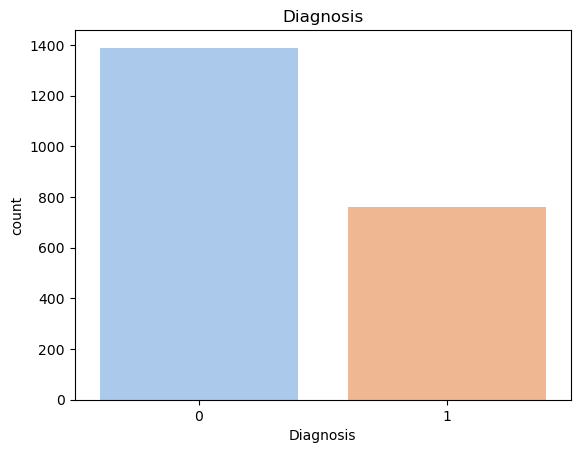

In [15]:
yesno_plot(df,"Diagnosis")

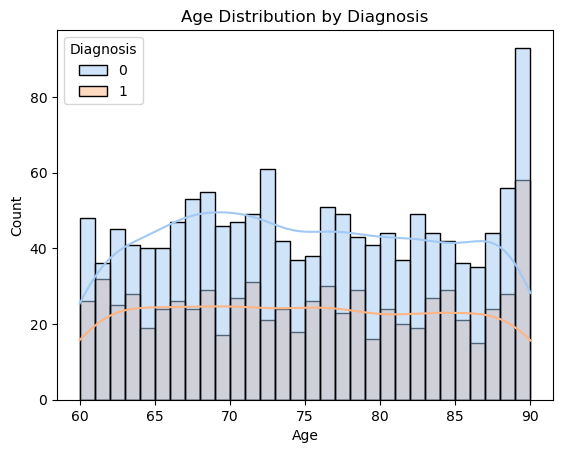

In [16]:
sns.histplot(
    data=df,
    x="Age",
    hue="Diagnosis",
    bins=30,
    kde=True
)
plt.title("Age Distribution by Diagnosis")
plt.show()

In [17]:
def pie(label,title=None):
    if not title:
        title = label

    val=df[label][df['Diagnosis']==1].value_counts().values
    index=df[label][df['Diagnosis']==1].value_counts().index
    fig = px.pie(values=val,names=index,title=title,width=400, height=400).update_traces(textinfo='label+percent')
    fig.show()

In [39]:
categorical_df = df.select_dtypes(include='int')
categorical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Age                        2149 non-null   int64
 1   Gender                     2149 non-null   int64
 2   Ethnicity                  2149 non-null   int64
 3   EducationLevel             2149 non-null   int64
 4   Smoking                    2149 non-null   int64
 5   FamilyHistoryAlzheimers    2149 non-null   int64
 6   CardiovascularDisease      2149 non-null   int64
 7   Diabetes                   2149 non-null   int64
 8   Depression                 2149 non-null   int64
 9   HeadInjury                 2149 non-null   int64
 10  Hypertension               2149 non-null   int64
 11  SystolicBP                 2149 non-null   int64
 12  DiastolicBP                2149 non-null   int64
 13  MemoryComplaints           2149 non-null   int64
 14  BehavioralProblems         2149 non

In [40]:
categorical_df = categorical_df.drop(columns=["Age","DiastolicBP", "SystolicBP"])

In [41]:
categorical_df_positive = categorical_df[categorical_df["Diagnosis"] == "Yes"]
categorical_positive_dicts = dict()

for i, column in enumerate(categorical_df_positive, 1):
    if column != "Country" and column != "Diagnosis":
        item = categorical_df[column].value_counts().to_dict()
        categorical_positive_dicts[column] = item

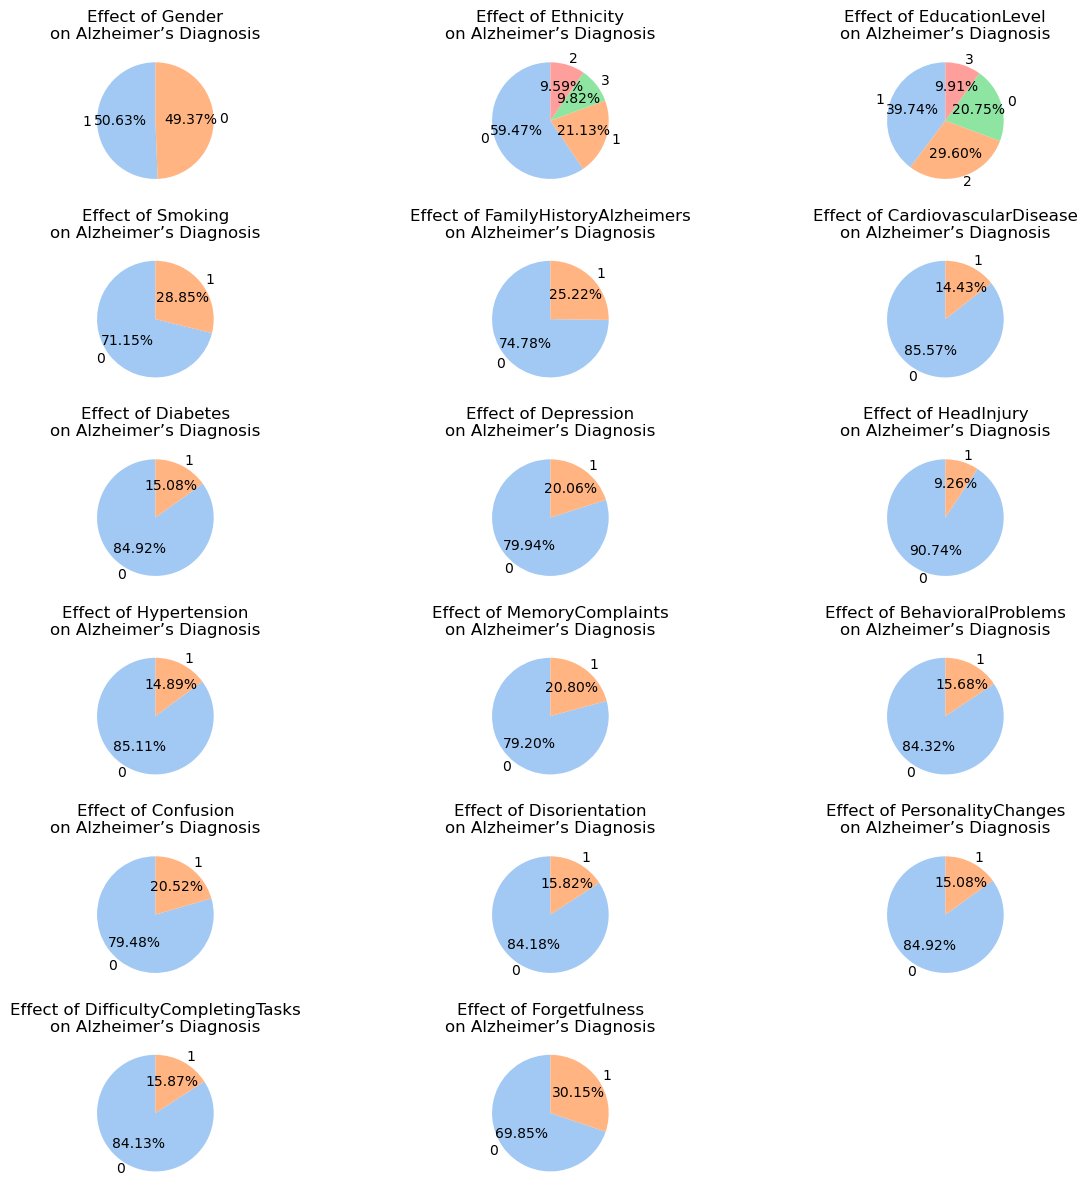

In [42]:
plt.figure(figsize=[12, 20])
i = 1

for key, value in categorical_positive_dicts.items():
    plt.subplot(10, 3, i)
    plt.pie(value.values(), labels=value.keys(), startangle=90, autopct="%.2f%%")
    plt.title("Effect of {}\non Alzheimer’s Diagnosis".format(key))
    i = i + 1

plt.tight_layout()
plt.show()

In [43]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='str')

# All but DoctorInCharge and PatientID

In [58]:
y = df['Diagnosis']

In [59]:
X = df.drop(columns='Diagnosis')

In [47]:
X.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0


In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [61]:
def train(X_train, X_test, y_train, y_test): 

    # Scale features (needed for LogReg + KNN; RF/GBM are scale-invariant)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    
    def evaluate(name, model, Xtr, Xte):
        start = time.time()
        model.fit(Xtr, y_train)
        fit_time = time.time() - start
    
        preds = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1]
    
        row = {
            'Model': name,
            'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds),
            'Recall': recall_score(y_test, preds),
            'F1': f1_score(y_test, preds),
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Fit Time (s)': round(fit_time, 2)
        }
        results.append(row)
        print(f"--- {name} ---")
        print(confusion_matrix(y_test, preds))
        print(classification_report(y_test, preds, target_names=['No', 'Yes']))
        return model
    
    # Logistic Regression
    log_reg = evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
                        X_train_scaled, X_test_scaled)
    lr_coef = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
    
    # Random Forest
    rf = evaluate('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                  X_train, X_test)
    rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    # Gradient Boosting
    gb = evaluate('Gradient Boosting', GradientBoostingClassifier(random_state=42),
                  X_train, X_test)
    gb_imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    
    knn = evaluate('KNN', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
                   X_train_scaled, X_test_scaled)
    
    results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
    print(results_df.to_string(index=False))
    print()
    print("=== Gradient Boosting: Top 15 Feature Importances ===")
    print(gb_imp.head(15))
    print()
    print("=== Random Forest: Top 15 Feature Importances ===")
    print(rf_imp.head(15))
    print()
    print("=== Logistic Regression: Top 15 Coefficients (by abs value) ===")
    print(lr_coef.head(15))

In [63]:
train(X_train, X_test, y_train, y_test)

--- Logistic Regression ---
[[239  39]
 [ 40 112]]
              precision    recall  f1-score   support

          No       0.86      0.86      0.86       278
         Yes       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430

--- Random Forest ---
[[270   8]
 [ 16 136]]
              precision    recall  f1-score   support

          No       0.94      0.97      0.96       278
         Yes       0.94      0.89      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430

--- Gradient Boosting ---
[[267  11]
 [ 12 140]]
              precision    recall  f1-score   support

          No       0.96      0.96      0.96       278
         Yes       0.93      0.92      0.92       152

    accuracy                         

# Drop the Biology

In [64]:
df = pd.read_csv("data/alzheimers_disease_data.csv")
df = df.drop(columns=["PatientID","DoctorInCharge"])
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='str')

In [66]:
# --- Drop the two genetic/family-history columns ---
df = df.drop(columns=['MMSE'])

Final shape: (74283, 25)


In [67]:
y = df["Diagnosis"]
X =  df.drop(columns='Diagnosis')

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [69]:
train(X_train, X_test, y_train, y_test)


--- Logistic Regression ---
[[227  51]
 [ 44 108]]
              precision    recall  f1-score   support

          No       0.84      0.82      0.83       278
         Yes       0.68      0.71      0.69       152

    accuracy                           0.78       430
   macro avg       0.76      0.76      0.76       430
weighted avg       0.78      0.78      0.78       430

--- Random Forest ---
[[234  44]
 [ 28 124]]
              precision    recall  f1-score   support

          No       0.89      0.84      0.87       278
         Yes       0.74      0.82      0.78       152

    accuracy                           0.83       430
   macro avg       0.82      0.83      0.82       430
weighted avg       0.84      0.83      0.83       430

--- Gradient Boosting ---
[[232  46]
 [ 27 125]]
              precision    recall  f1-score   support

          No       0.90      0.83      0.86       278
         Yes       0.73      0.82      0.77       152

    accuracy                         

In [70]:
df = pd.read_csv("data/alzheimers_disease_data.csv")

In [71]:
df = df.drop(columns=["PatientID","DoctorInCharge", 'MMSE','Age','ADL','FunctionalAssessment','MemoryComplaints', 'BehavioralProblems' ])
y = df["Diagnosis"]
X =  df.drop(columns='Diagnosis')

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [73]:
train(X_train, X_test, y_train, y_test)

--- Logistic Regression ---
[[275   3]
 [149   3]]
              precision    recall  f1-score   support

          No       0.65      0.99      0.78       278
         Yes       0.50      0.02      0.04       152

    accuracy                           0.65       430
   macro avg       0.57      0.50      0.41       430
weighted avg       0.60      0.65      0.52       430

--- Random Forest ---
[[271   7]
 [148   4]]
              precision    recall  f1-score   support

          No       0.65      0.97      0.78       278
         Yes       0.36      0.03      0.05       152

    accuracy                           0.64       430
   macro avg       0.51      0.50      0.41       430
weighted avg       0.55      0.64      0.52       430

--- Gradient Boosting ---
[[260  18]
 [139  13]]
              precision    recall  f1-score   support

          No       0.65      0.94      0.77       278
         Yes       0.42      0.09      0.14       152

    accuracy                         